# PageRank and KNN: a graph view

K-nearest-neighbor methods and PageRank look unrelated at first.

- **KNN** starts with a point and asks: *which other points are most similar to it?*
- **PageRank** starts with a graph and asks: *which nodes receive the most importance from the graph?*

The connection appears when we build a **similarity graph** from the data. Each observation becomes a node. Edge weights encode similarity. A KNN graph keeps only the strongest local similarities. PageRank then measures how much importance flows to each node through that graph.

The key idea is simple:

> On an undirected weighted graph, PageRank behaves like a smoothed version of weighted degree. A KNN score based on total neighborhood similarity is also a weighted-degree score.

So the two rankings are not identical in every graph, but they are closely related when the graph is symmetric and local-neighborhood structure is the main signal.


## Setup

We use a synthetic two-cluster dataset. The example is deliberately small enough to inspect, but large enough to show the ranking behavior.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

np.random.seed(7)
plt.style.use("seaborn-v0_8-whitegrid")


## Build a similarity graph

Start with points in Euclidean space. Convert pairwise distances into similarities using a Gaussian kernel:

$$
W_{ij} = \exp\left(-\frac{\lVert x_i - x_j \rVert^2}{2\sigma^2}\right)
$$

Then keep only the top `k` neighbors for each point. Finally, symmetrize the graph so that if either point considers the other a neighbor, the undirected edge is retained.


In [2]:
def make_dataset(n_per_cluster=35, spread=0.45):
    cluster_a = np.random.normal(loc=(-1.2, 0.0), scale=spread, size=(n_per_cluster, 2))
    cluster_b = np.random.normal(loc=(1.2, 0.2), scale=spread, size=(n_per_cluster, 2))
    X = np.vstack([cluster_a, cluster_b])
    labels = np.array([0] * n_per_cluster + [1] * n_per_cluster)
    return X, labels


def pairwise_sq_dist(X):
    diff = X[:, None, :] - X[None, :, :]
    return np.sum(diff * diff, axis=2)


def knn_similarity_graph(X, k=8, sigma=None):
    D2 = pairwise_sq_dist(X)
    n = D2.shape[0]

    if sigma is None:
        nonzero = D2[D2 > 0]
        sigma = np.sqrt(np.median(nonzero))

    W_full = np.exp(-D2 / (2 * sigma**2))
    np.fill_diagonal(W_full, 0.0)

    W_knn = np.zeros_like(W_full)
    for i in range(n):
        neighbors = np.argsort(-W_full[i])[:k]
        W_knn[i, neighbors] = W_full[i, neighbors]

    # Undirected KNN graph: keep an edge if either endpoint selected it.
    W = np.maximum(W_knn, W_knn.T)
    return W, sigma


X, labels = make_dataset()
W, sigma = knn_similarity_graph(X, k=8)

print(f"points: {len(X)}")
print(f"sigma: {sigma:.3f}")
print(f"nonzero weighted edges: {np.count_nonzero(W) // 2}")


points: 70
sigma: 1.570
nonzero weighted edges: 351


## Visualize the KNN graph

Dense regions should have more and stronger local links. Boundary points or isolated points should have fewer strong connections.


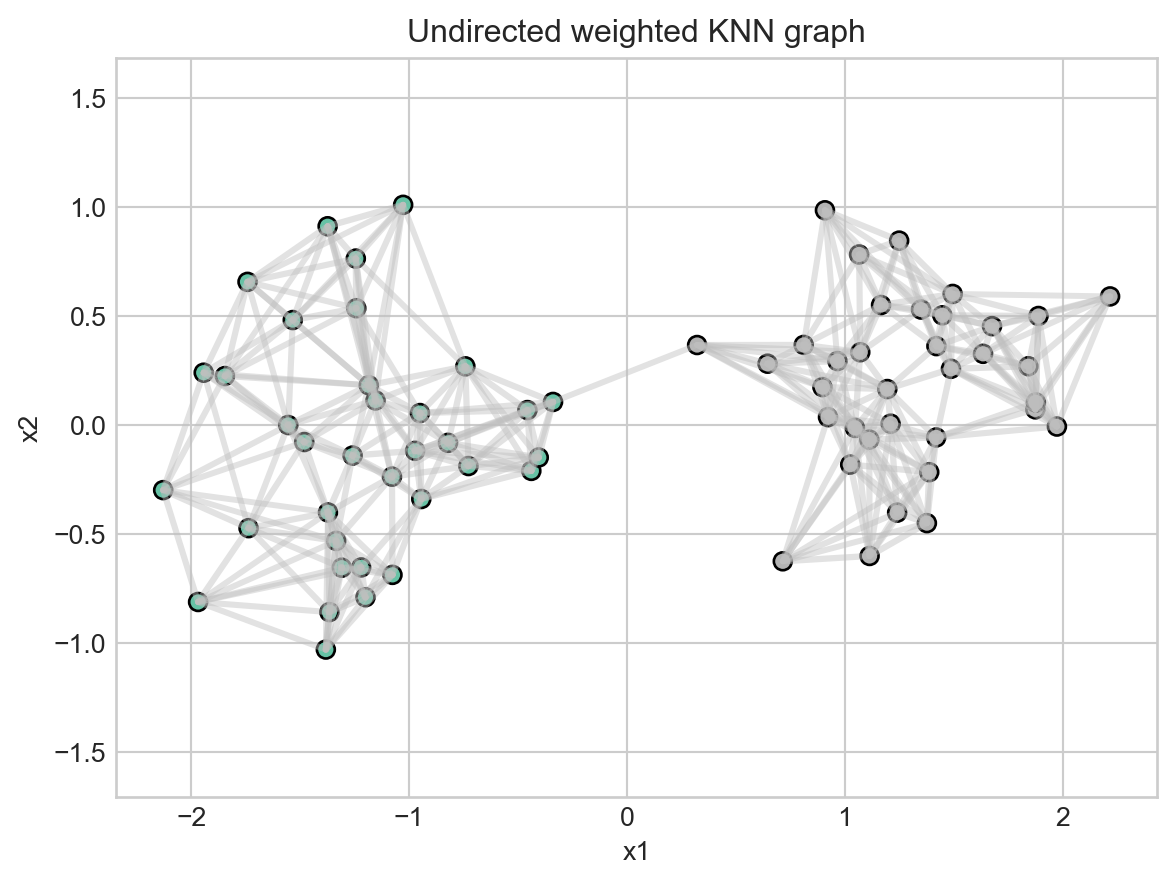

In [3]:
def plot_knn_graph(X, W, labels):
    fig, ax = plt.subplots(figsize=(7, 5))

    for i in range(W.shape[0]):
        for j in range(i + 1, W.shape[1]):
            if W[i, j] > 0:
                ax.plot(
                    [X[i, 0], X[j, 0]],
                    [X[i, 1], X[j, 1]],
                    color="0.75",
                    linewidth=0.6 + 1.8 * W[i, j],
                    alpha=0.45,
                )

    scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, s=45, cmap="Set2", edgecolor="black")
    ax.set_title("Undirected weighted KNN graph")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.axis("equal")
    return fig, ax

plot_knn_graph(X, W, labels);


## Two scores on the same graph

Once we have the graph, there are two natural scores.

**1. Weighted KNN score**

For each node, sum the weights of its incident edges:

$$
d_i = \sum_j W_{ij}
$$

This is a weighted-degree score. In KNN language, it says: *how much total similarity mass is attached to this point?*

**2. PageRank score**

PageRank normalizes outgoing edge weights into transition probabilities and computes the stationary importance score with teleportation:

$$
\pi = \alpha P^T\pi + (1 - \alpha)v
$$

On an undirected weighted graph, this is a smoothed version of weighted degree. Teleportation prevents zero-probability traps and slightly flattens the ranking.


In [4]:
def weighted_degree_score(W):
    score = W.sum(axis=1)
    return score / score.sum()


def pagerank_score(W, alpha=0.85, tol=1e-12, max_iter=500):
    """Compute PageRank directly from a weighted adjacency matrix.

    Rows of ``W`` represent outgoing edge weights. Dangling rows are replaced
    with a uniform transition distribution.
    """
    n = W.shape[0]
    row_sums = W.sum(axis=1, keepdims=True)
    P = np.divide(W, row_sums, out=np.ones_like(W) / n, where=row_sums > 0)

    rank = np.ones(n) / n
    teleport = np.ones(n) / n

    for _ in range(max_iter):
        new_rank = alpha * P.T @ rank + (1 - alpha) * teleport
        if np.linalg.norm(new_rank - rank, ord=1) < tol:
            return new_rank
        rank = new_rank

    return rank


def rank_order(score):
    return np.argsort(-score)


def top_k_overlap(a, b, k):
    return len(set(rank_order(a)[:k]).intersection(rank_order(b)[:k])) / k


knn_score = weighted_degree_score(W)
pr_score = pagerank_score(W)

print("top 10 by weighted KNN score:", rank_order(knn_score)[:10])
print("top 10 by PageRank:          ", rank_order(pr_score)[:10])
for k in [5, 10, 20]:
    print(f"top-{k} overlap: {top_k_overlap(knn_score, pr_score, k):.2f}")


top 10 by weighted KNN score: [49  1 46 32  6 55 26 61 24 56]
top 10 by PageRank:           [49  1 32 46  6 26 55 34 56 40]
top-5 overlap: 1.00
top-10 overlap: 0.80
top-20 overlap: 0.90


## Compare the rankings

If the equivalence intuition is right, PageRank and weighted KNN score should be strongly aligned. A scatter plot makes this easier to see.


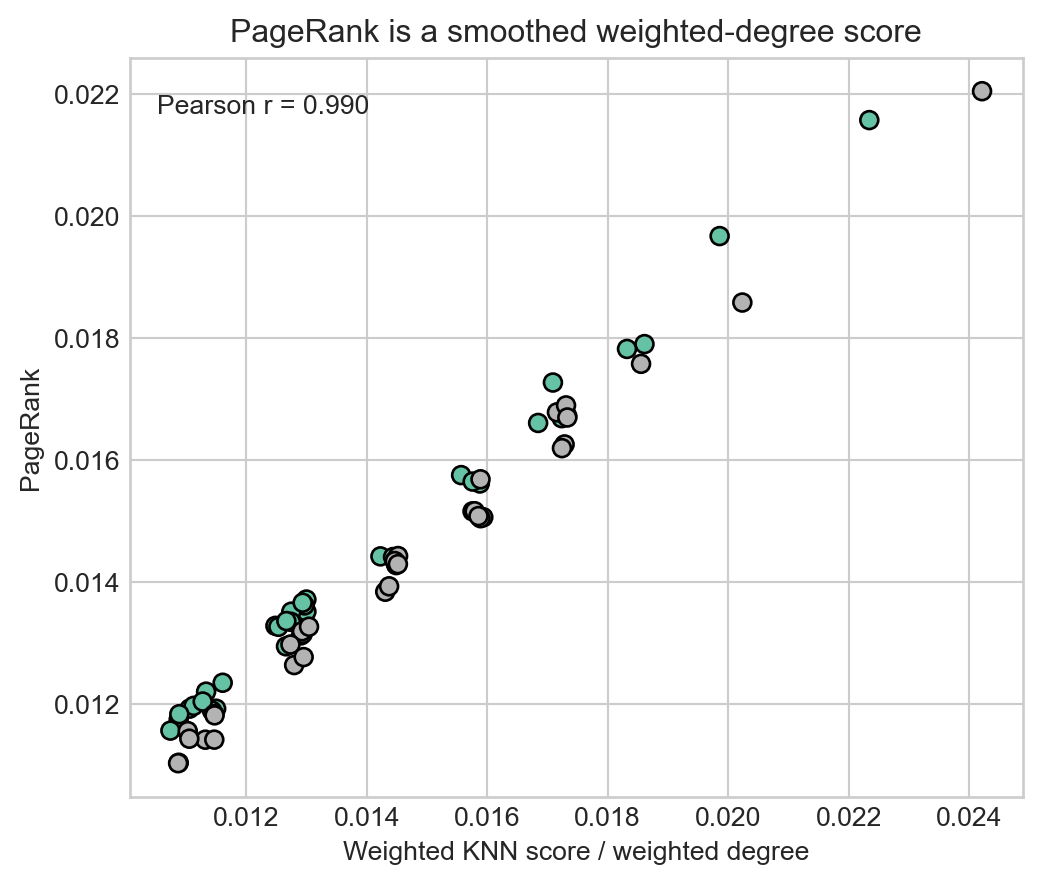

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(knn_score, pr_score, c=labels, cmap="Set2", s=45, edgecolor="black")
ax.set_xlabel("Weighted KNN score / weighted degree")
ax.set_ylabel("PageRank")
ax.set_title("PageRank is a smoothed weighted-degree score")

corr = np.corrcoef(knn_score, pr_score)[0, 1]
ax.text(0.03, 0.95, f"Pearson r = {corr:.3f}", transform=ax.transAxes, va="top")
plt.show()


## Why the relationship holds

For an undirected weighted graph, the random walk transition matrix is built by normalizing edge weights by degree:

$$
P_{ij} = \frac{W_{ij}}{d_i}
$$

Without teleportation, the stationary distribution of this random walk is proportional to weighted degree:

$$
\pi_i = \frac{d_i}{\sum_j d_j}
$$

PageRank adds teleportation. With teleportation, the score is no longer exactly the degree distribution, but it remains close when the graph is well connected and the teleportation rate is not too large.

That is the practical equivalence:

> KNN neighborhood mass gives local similarity importance. PageRank gives graph-smoothed similarity importance.


## A small simulation

The relationship should remain stable across many random datasets. We generate many two-cluster datasets, build KNN graphs, and measure how often the top-ranked nodes agree.


In [6]:
def run_trial(n_per_cluster=35, k_neighbors=8):
    X, labels = make_dataset(n_per_cluster=n_per_cluster)
    W, _ = knn_similarity_graph(X, k=k_neighbors)
    knn = weighted_degree_score(W)
    pr = pagerank_score(W)
    return {
        "corr": np.corrcoef(knn, pr)[0, 1],
        "top_5": top_k_overlap(knn, pr, 5),
        "top_10": top_k_overlap(knn, pr, 10),
        "top_20": top_k_overlap(knn, pr, 20),
    }


trials = [run_trial() for _ in range(100)]
summary = {key: np.mean([trial[key] for trial in trials]) for key in trials[0]}
summary


{'corr': np.float64(0.9885670778727581),
 'top_5': np.float64(0.8179999999999998),
 'top_10': np.float64(0.8450000000000002),
 'top_20': np.float64(0.914)}

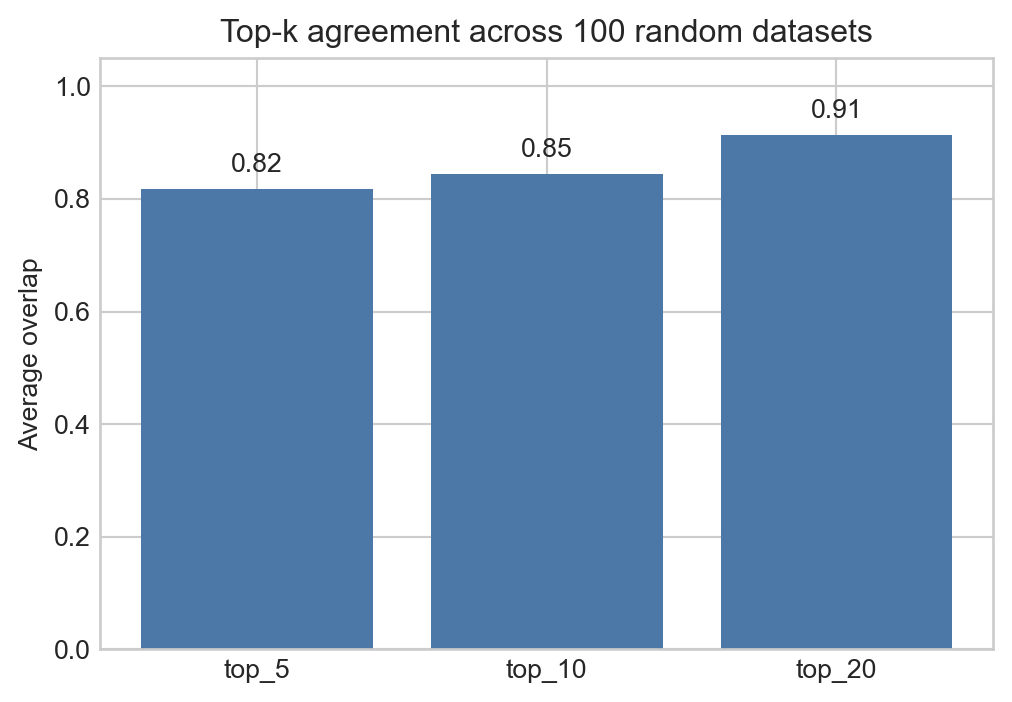

average Pearson correlation: 0.989


In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
keys = ["top_5", "top_10", "top_20"]
ax.bar(keys, [summary[k] for k in keys], color="#4C78A8")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Average overlap")
ax.set_title("Top-k agreement across 100 random datasets")
for i, key in enumerate(keys):
    ax.text(i, summary[key] + 0.03, f"{summary[key]:.2f}", ha="center")
plt.show()

print(f"average Pearson correlation: {summary['corr']:.3f}")


## Where Sinkhorn fits

The original experiment used **Sinkhorn normalization** to build a doubly stochastic matrix. That is worth keeping, because Sinkhorn and PageRank are connected at the level of *iterative normalization*.

They are not solving the same problem:

- **Sinkhorn** repeatedly rescales rows and columns until a nonnegative matrix has prescribed row and column sums, usually all ones. It is balancing a matrix.
- **PageRank** repeatedly applies a Markov transition operator until a probability vector reaches a stationary fixed point. It is finding long-run node importance.

But both are fixed-point iterations over nonnegative objects:

- Sinkhorn alternates between row normalization and column normalization.
- PageRank alternates probability propagation and teleportation.

So the connection is conceptual and computational: both use repeated normalization to make an object probabilistically meaningful. Sinkhorn produces a balanced transition-like matrix; PageRank computes the stationary distribution of a transition matrix.


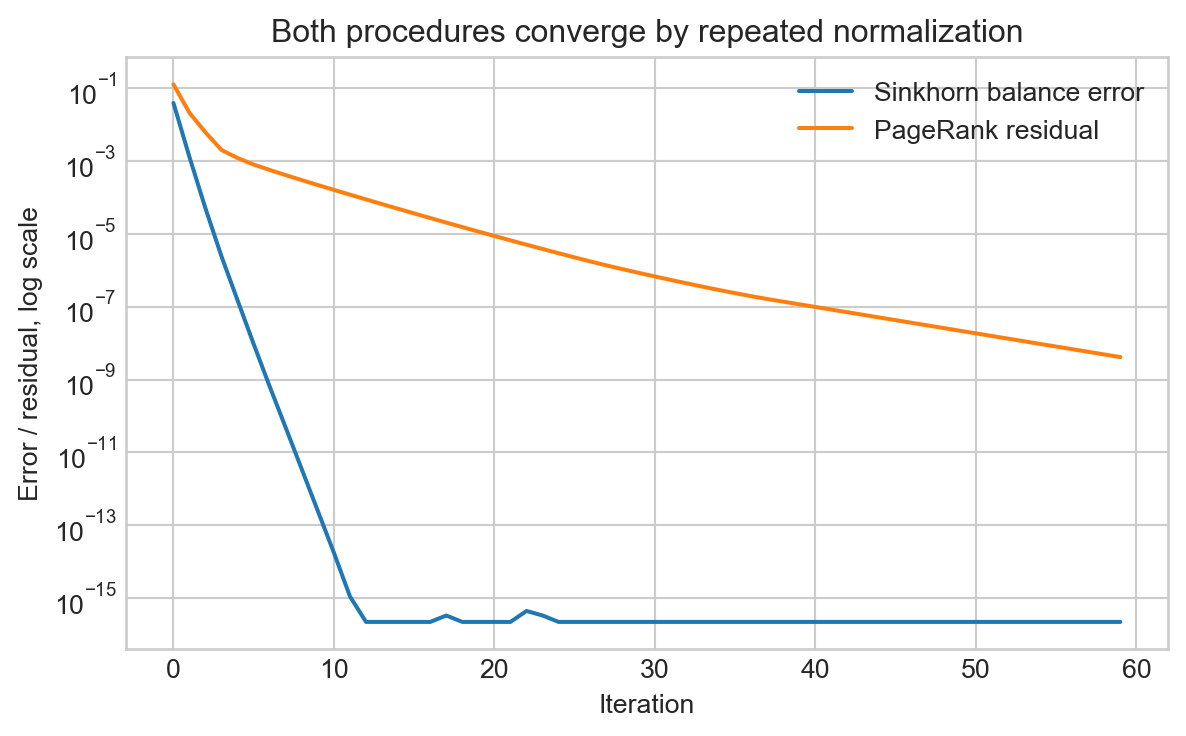

balanced matrix row sums, first 5: [1. 1. 1. 1. 1.]
balanced matrix col sums, first 5: [1. 1. 1. 1. 1.]


In [8]:
def sinkhorn_balance(X, max_iter=100, eps=1e-12, return_history=False):
    """Balance a nonnegative matrix so rows and columns approximately sum to one."""
    Y = X.copy().astype(float)
    history = []

    for _ in range(max_iter):
        Y = Y / np.maximum(Y.sum(axis=1, keepdims=True), eps)
        Y = Y / np.maximum(Y.sum(axis=0, keepdims=True), eps)

        if return_history:
            row_error = np.max(np.abs(Y.sum(axis=1) - 1))
            col_error = np.max(np.abs(Y.sum(axis=0) - 1))
            history.append(max(row_error, col_error))

    if return_history:
        return Y, np.array(history)
    return Y


def pagerank_score_with_history(W, alpha=0.85, tol=1e-12, max_iter=100):
    """PageRank with residual history for comparison with Sinkhorn."""
    n = W.shape[0]
    row_sums = W.sum(axis=1, keepdims=True)
    P = np.divide(W, row_sums, out=np.ones_like(W) / n, where=row_sums > 0)

    rank = np.ones(n) / n
    teleport = np.ones(n) / n
    history = []

    for _ in range(max_iter):
        new_rank = alpha * P.T @ rank + (1 - alpha) * teleport
        residual = np.linalg.norm(new_rank - rank, ord=1)
        history.append(residual)
        rank = new_rank
        if residual < tol:
            break

    return rank, np.array(history)


A = np.random.rand(20, 20)
S, sinkhorn_history = sinkhorn_balance(A, max_iter=60, return_history=True)
_, pagerank_history = pagerank_score_with_history(W, max_iter=60)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(sinkhorn_history, label="Sinkhorn balance error")
ax.semilogy(pagerank_history, label="PageRank residual")
ax.set_xlabel("Iteration")
ax.set_ylabel("Error / residual, log scale")
ax.set_title("Both procedures converge by repeated normalization")
ax.legend()
plt.show()

print("balanced matrix row sums, first 5:", np.round(S.sum(axis=1)[:5], 4))
print("balanced matrix col sums, first 5:", np.round(S.sum(axis=0)[:5], 4))


The plot should not be read as a speed benchmark. The two residuals measure different things. The point is structural: both procedures turn repeated local updates into a global probabilistic object.

This also explains why the doubly stochastic case is special. Once Sinkhorn has balanced a symmetric similarity matrix, every node has the same total outgoing and incoming mass. PageRank on that balanced graph becomes uniform, so it no longer gives a useful ranking.


## The doubly stochastic special case

A matrix is **doubly stochastic** if every row and every column sums to one. If a graph transition matrix is doubly stochastic, the stationary distribution is uniform. PageRank is also uniform when teleportation is uniform.

That is a useful edge case, but it is not a useful ranking experiment: every node ties. If we compare ranks after sorting tied scores, we are mostly measuring tie-breaking behavior, not a meaningful equivalence.


In [9]:
def sinkhorn(X, max_iter=100, eps=1e-12):
    Y = X.copy().astype(float)
    for _ in range(max_iter):
        Y = Y / np.maximum(Y.sum(axis=1, keepdims=True), eps)
        Y = Y / np.maximum(Y.sum(axis=0, keepdims=True), eps)
    return Y


A = np.random.rand(6, 6)
A = (A + A.T) / 2
S = sinkhorn(A)

print("row sums:", np.round(S.sum(axis=1), 4))
print("col sums:", np.round(S.sum(axis=0), 4))
print("PageRank:", np.round(pagerank_score(S), 4))
print("weighted degree:", np.round(weighted_degree_score(S), 4))


row sums: [1. 1. 1. 1. 1. 1.]
col sums: [1. 1. 1. 1. 1. 1.]
PageRank: [0.1667 0.1667 0.1667 0.1667 0.1667 0.1667]
weighted degree: [0.1667 0.1667 0.1667 0.1667 0.1667 0.1667]


## Takeaway

KNN and PageRank are not the same algorithm. But when KNN is viewed as a weighted similarity graph, the connection becomes clear:

- KNN keeps local similarity edges.
- Weighted degree measures how much local similarity mass a node has.
- PageRank propagates and smooths that importance over the graph.

On undirected weighted graphs, PageRank is therefore best read as a graph-smoothed KNN-neighborhood score. The more regular the graph, the closer PageRank becomes to weighted degree; in the doubly stochastic case, both collapse to the uniform distribution.
